In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
from pathlib import Path
import pickle
from dataclasses import dataclass, asdict

In [7]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, TensorDataset


In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve, roc_curve
)

In [9]:
!pip install mlflow
import mlflow
import mlflow.pytorch
import mlflow.sklearn

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [11]:
{DEVICE}

{'cpu'}

In [13]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("notebook-baseline")


<Experiment: artifact_location='/Users/tulikasingh/Desktop/RealTime-Network-Anomaly-Detection/mlruns/1', creation_time=1781118935126, experiment_id='1', last_update_time=1781118935126, lifecycle_stage='active', name='notebook-baseline', tags={}>

In [14]:
client = mlflow.tracking.MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active experiment: {mlflow.get_experiment_by_name('notebook-baseline').name}")

Tracking URI: http://localhost:5000
Active experiment: notebook-baseline


In [19]:
FEATURE_COLS = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Fwd Packet Length Mean", "Bwd Packet Length Mean",
    "Flow Bytes/s", "Flow Packets/s",
    "Flow IAT Mean", "Fwd IAT Mean", "Bwd IAT Mean",
    "Packet Length Mean", "Packet Length Std",
    "SYN Flag Count", "ACK Flag Count", "Average Packet Size",
]

In [20]:
LABEL_COL = "Label"
DATA_DIR = Path("../data/raw")

In [21]:
def load_raw(data_dir):
    csvs = sorted(Path(data_dir).glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSVs in {data_dir} — see synthetic-data cell below")
    print(f"Loading {len(csvs)} CSVs...")
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csvs], ignore_index=True)
    df.columns = df.columns.str.strip()  
    return df

In [22]:
def clean_data(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=FEATURE_COLS + [LABEL_COL])
    print(f"Dropped {before - len(df):,} rows with NaN/inf")
    df["label_binary"] = (df[LABEL_COL].str.strip() != "BENIGN").astype(int)
    return df

In [23]:
df = clean_data(load_raw(DATA_DIR))
print(f"\nTotal rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head(3)

Loading 8 CSVs...
Dropped 2,867 rows with NaN/inf

Total rows: 2,827,876
Columns: 80


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,label_binary
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0


In [24]:
print("Class distribution:")
print(df["label_binary"].value_counts())
print(f"\nAttack ratio: {df['label_binary'].mean():.4%}")

print("\nOriginal attack types:")
print(df[df["label_binary"] == 1][LABEL_COL].value_counts().head(10))

Class distribution:
label_binary
0    2271320
1     556556
Name: count, dtype: int64

Attack ratio: 19.6811%

Original attack types:
Label
DoS Hulk                    230124
PortScan                    158804
DDoS                        128025
DoS GoldenEye                10293
FTP-Patator                   7935
SSH-Patator                   5897
DoS slowloris                 5796
DoS Slowhttptest              5499
Bot                           1956
Web Attack � Brute Force      1507
Name: count, dtype: int64


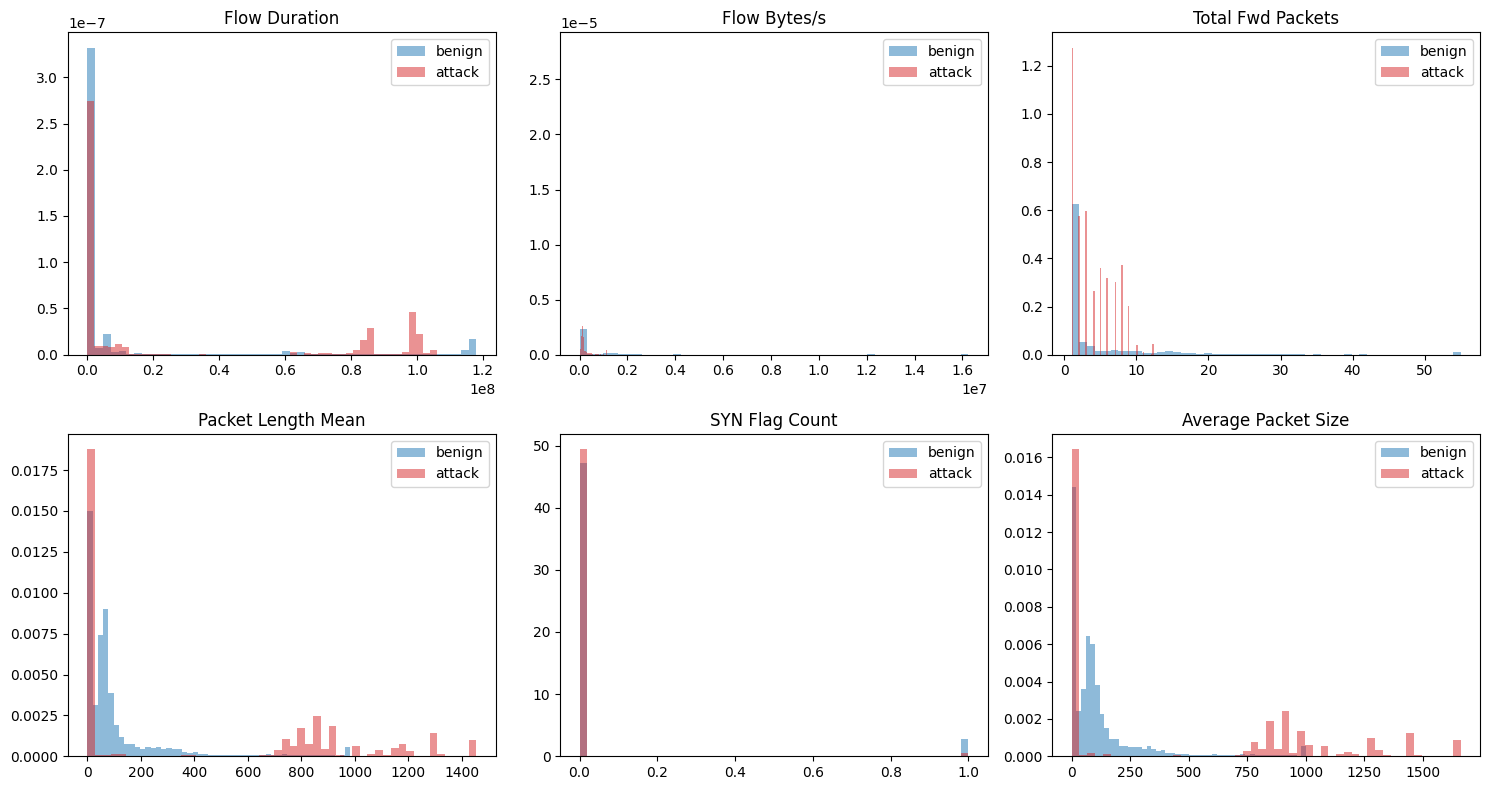

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ["Flow Duration", "Flow Bytes/s", "Total Fwd Packets",
                    "Packet Length Mean", "SYN Flag Count", "Average Packet Size"]
for ax, feat in zip(axes.flat, features_to_plot):
    for label, color in [(0, "tab:blue"), (1, "tab:red")]:
        data = df[df["label_binary"] == label][feat]
        # Clip extreme values for visualization
        clipped = np.clip(data, data.quantile(0.01), data.quantile(0.99))
        ax.hist(clipped, bins=50, alpha=0.5, color=color,
                label=("benign" if label == 0 else "attack"), density=True)
    ax.set_title(feat); ax.legend()
plt.tight_layout(); plt.show()

In [26]:
X = df[FEATURE_COLS].values.astype(np.float32)
y = df["label_binary"].values.astype(np.int64)

In [27]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=SEED)

In [28]:
print(f"Train: {len(X_train_full):,} ({y_train_full.mean():.4%} attacks)")
print(f"Val:   {len(X_val):,} ({y_val.mean():.4%} attacks)")
print(f"Test:  {len(X_test):,} ({y_test.mean():.4%} attacks)")

Train: 1,979,512 (19.6811% attacks)
Val:   282,788 (19.6812% attacks)
Test:  565,576 (19.6810% attacks)


In [29]:
scaler = StandardScaler().fit(X_train_full[y_train_full == 0])

In [30]:
X_train_scaled_full = scaler.transform(X_train_full)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_benign = X_train_scaled_full[y_train_full == 0]
print(f"Benign-only train set for LSTM AE: {len(X_train_benign):,}")

Benign-only train set for LSTM AE: 1,589,923


In [32]:
def evaluate_detector(scores, preds, y_true, name=""):
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
    metrics = {
        "auc_roc": float(roc_auc_score(y_true, scores)),
        "auc_pr": float(average_precision_score(y_true, scores)),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
    }
    print(f"\n{name} test metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics

In [33]:
with mlflow.start_run(run_name="isolation_forest_baseline") as run:
    mlflow.log_params({"model": "isolation_forest", "n_estimators": 200,
                       "contamination": 0.01, "seed": SEED})

    iforest = IsolationForest(n_estimators=200, contamination=0.01,
                              random_state=SEED, n_jobs=-1)
    iforest.fit(X_train_scaled_full)

    if_scores = -iforest.decision_function(X_test_scaled)
    if_preds = (iforest.predict(X_test_scaled) == -1).astype(int)

    if_metrics = evaluate_detector(if_scores, if_preds, y_test, "Isolation Forest")
    mlflow.log_metrics(if_metrics)
    mlflow.sklearn.log_model(iforest, "model", registered_model_name="network-anomaly-detector")
    IF_RUN_ID = run.info.run_id
    print(f"\nLogged to MLflow run: {IF_RUN_ID}")


Isolation Forest test metrics:
  auc_roc: 0.6618
  auc_pr: 0.3351
  precision: 0.0543
  recall: 0.0028
  f1: 0.0053


Successfully registered model 'network-anomaly-detector'.
2026/06/15 07:05:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: network-anomaly-detector, version 1



Logged to MLflow run: 3f492de5262b48228faea52e384e8c5b


Created version '1' of model 'network-anomaly-detector'.


# Trained Isolation Forest

In [35]:
@dataclass
class LSTMConfig:
    seq_len: int = 15
    input_dim: int = 1
    hidden_dim: int = 32
    latent_dim: int = 8
    num_layers: int = 1
    lr: float = 1e-3
    batch_size: int = 256
    epochs: int = 20

In [36]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = nn.LSTM(cfg.input_dim, cfg.hidden_dim, cfg.num_layers, batch_first=True)
        self.to_latent = nn.Linear(cfg.hidden_dim, cfg.latent_dim)
        self.from_latent = nn.Linear(cfg.latent_dim, cfg.hidden_dim)
        self.decoder = nn.LSTM(cfg.hidden_dim, cfg.hidden_dim, cfg.num_layers, batch_first=True)
        self.output = nn.Linear(cfg.hidden_dim, cfg.input_dim)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.to_latent(h[-1])
        h_dec = self.from_latent(z).unsqueeze(0)
        decoder_input = h_dec.permute(1, 0, 2).repeat(1, self.cfg.seq_len, 1)
        decoded, _ = self.decoder(decoder_input)
        return self.output(decoded)


def to_seq(X):
    return torch.tensor(X, dtype=torch.float32).unsqueeze(-1)

epoch 1/20  loss=0.33474
epoch 2/20  loss=0.13224
epoch 3/20  loss=0.11050
epoch 4/20  loss=0.09152
epoch 5/20  loss=0.07716
epoch 6/20  loss=0.07013
epoch 7/20  loss=0.07006
epoch 8/20  loss=0.05756
epoch 9/20  loss=0.05142
epoch 10/20  loss=0.04906
epoch 11/20  loss=0.04024
epoch 12/20  loss=0.04561
epoch 13/20  loss=0.03627
epoch 14/20  loss=0.03087
epoch 15/20  loss=0.02985
epoch 16/20  loss=0.03040
epoch 17/20  loss=0.02699
epoch 18/20  loss=0.02415
epoch 19/20  loss=0.02036
epoch 20/20  loss=0.02151


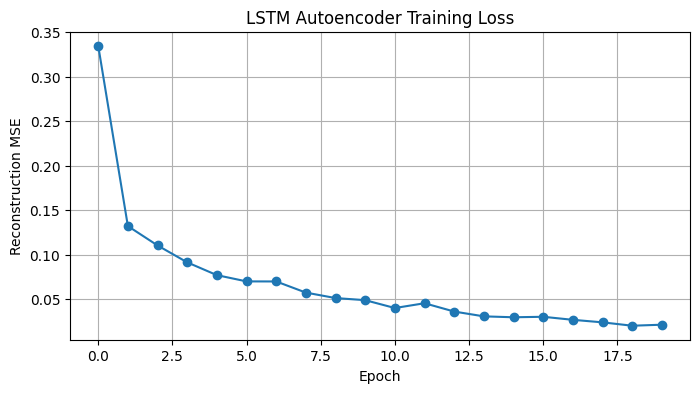

In [37]:
cfg = LSTMConfig(seq_len=15, epochs=20)
model = LSTMAutoencoder(cfg).to(DEVICE)
opt = optim.Adam(model.parameters(), lr=cfg.lr)
loss_fn = nn.MSELoss()

train_ds = TensorDataset(to_seq(X_train_benign))
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)

train_losses = []
for epoch in range(cfg.epochs):
    model.train()
    total = 0.0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(batch), batch)
        loss.backward()
        opt.step()
        total += loss.item() * batch.size(0)
    avg = total / len(train_ds)
    train_losses.append(avg)
    print(f"epoch {epoch+1}/{cfg.epochs}  loss={avg:.5f}")

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction MSE")
plt.title("LSTM Autoencoder Training Loss")
plt.grid(True); plt.show()

 ### Pick a threshold

We use the **95th percentile of reconstruction error on the validation set** as the threshold. Anything above is flagged as anomaly. You can tune this — higher threshold = fewer false positives but more missed attacks.


Threshold (95th percentile of val errors): 0.30968


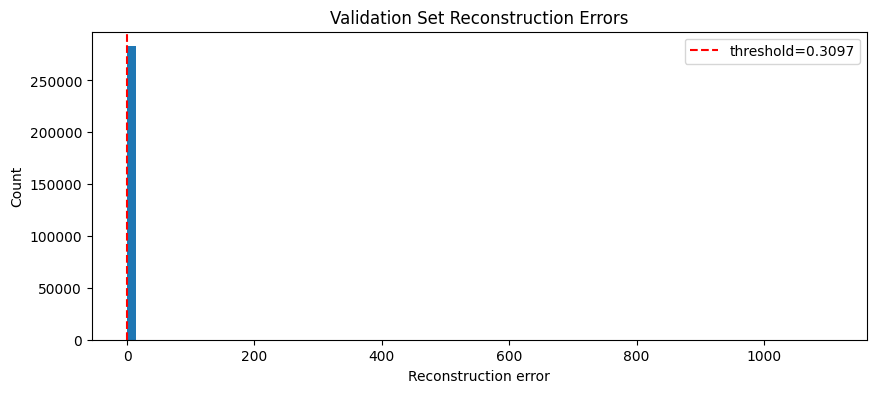

In [ ]:
@torch.no_grad()
def score_lstm(model, X):
    model.eval()
    x = to_seq(X).to(DEVICE)
    recon = model(x)
    return ((recon - x) ** 2).mean(dim=(1, 2)).cpu().numpy()


val_scores = score_lstm(model, X_val_scaled)
threshold = float(np.percentile(val_scores, 95))
print(f"Threshold (95th percentile of val errors): {threshold:.5f}")

# view of the score of distribution on validation
plt.figure(figsize=(10, 4))
plt.hist(val_scores, bins=80)
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
plt.xlabel("Reconstruction error"); plt.ylabel("Count")
plt.title("Validation Set Reconstruction Errors")
plt.legend(); plt.show()

In [40]:
with mlflow.start_run(run_name="lstm_autoencoder") as run:
    mlflow.log_params({k: v for k, v in asdict(cfg).items()})
    mlflow.log_param("model", "lstm_autoencoder")
    mlflow.log_param("threshold", threshold)

    lstm_scores = score_lstm(model, X_test_scaled)
    lstm_preds = (lstm_scores > threshold).astype(int)

    lstm_metrics = evaluate_detector(lstm_scores, lstm_preds, y_test, "LSTM Autoencoder")
    mlflow.log_metrics(lstm_metrics)

    # Save checkpoint
    ckpt_dir = Path("../checkpoints")
    ckpt_dir.mkdir(exist_ok=True)
    ckpt = ckpt_dir / f"{run.info.run_id}.pt"
    torch.save({"model": model.state_dict(), "cfg": asdict(cfg), "threshold": threshold}, ckpt)
    mlflow.log_artifact(str(ckpt), "model")

    scaler_path = ckpt_dir / f"{run.info.run_id}_scaler.pkl"
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    mlflow.log_artifact(str(scaler_path), "model")

    mlflow.pytorch.log_model(model, "pytorch_model",
                             registered_model_name="network-anomaly-detector")

    LSTM_RUN_ID = run.info.run_id
    print(f"\nLogged to MLflow run: {LSTM_RUN_ID}")
    print(f"Checkpoint: {ckpt}")
    print(f"Scaler: {scaler_path}")


LSTM Autoencoder test metrics:
  auc_roc: 0.7564
  auc_pr: 0.6183
  precision: 0.9886
  recall: 0.2550
  f1: 0.4055


Python(18218) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Registered model 'network-anomaly-detector' already exists. Creating a new version of this model...
2026/06/15 07:39:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: network-anomaly-detector, version 2



Logged to MLflow run: 4899c8cfe935403eabd15e7d6564d77c
Checkpoint: ../checkpoints/4899c8cfe935403eabd15e7d6564d77c.pt
Scaler: ../checkpoints/4899c8cfe935403eabd15e7d6564d77c_scaler.pkl


Created version '2' of model 'network-anomaly-detector'.


# Trained LSTM autoencoder

# Comparing the two models

                  auc_roc  auc_pr  precision  recall      f1
Isolation Forest   0.6618  0.3351     0.0543  0.0028  0.0053
LSTM Autoencoder   0.7564  0.6183     0.9886  0.2550  0.4055


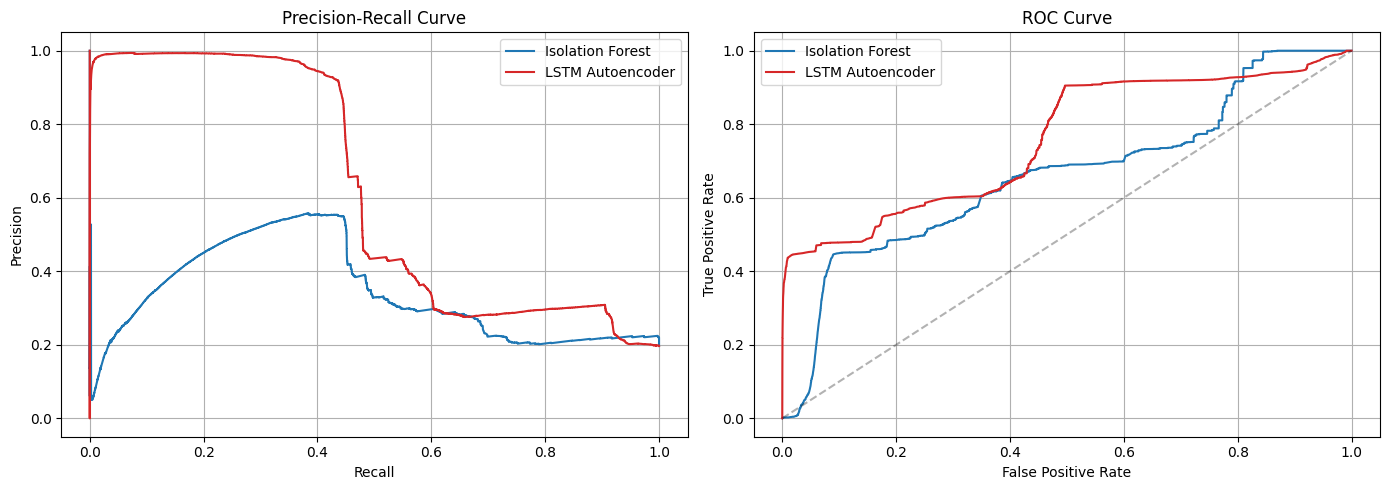

In [41]:
comparison = pd.DataFrame({
    "Isolation Forest": if_metrics,
    "LSTM Autoencoder": lstm_metrics,
}).T
print(comparison.round(4))

# Side-by-side PR curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for scores, name, color in [(if_scores, "Isolation Forest", "tab:blue"),
                             (lstm_scores, "LSTM Autoencoder", "tab:red")]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax[0].plot(recall, precision, label=name, color=color)

    fpr, tpr, _ = roc_curve(y_test, scores)
    ax[1].plot(fpr, tpr, label=name, color=color)

ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Precision-Recall Curve"); ax[0].legend(); ax[0].grid(True)

ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve"); ax[1].legend(); ax[1].grid(True)
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.tight_layout(); plt.show()

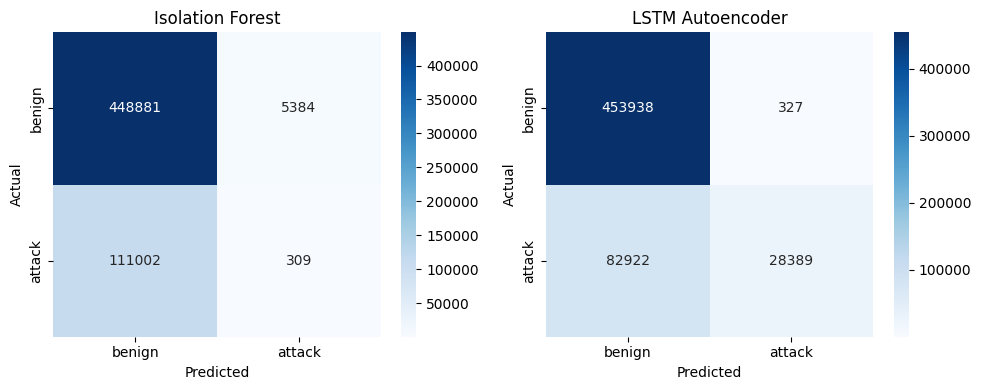

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, name in [(axes[0], if_preds, "Isolation Forest"),
                         (axes[1], lstm_preds, "LSTM Autoencoder")]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["benign", "attack"], yticklabels=["benign", "attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(name)
plt.tight_layout(); plt.show()

## Clearly lstm-autoencoder has a better performance hence we push it to prod in mlflow

# Saving reference dataset for drift detection

In [43]:
ref_dir = Path("../data/reference")
ref_dir.mkdir(parents=True, exist_ok=True)

# Sample 10k benign training points (scaled) — that's our reference
ref_sample = pd.DataFrame(
    X_train_benign[np.random.choice(len(X_train_benign), size=10000, replace=False)],
    columns=FEATURE_COLS
)
ref_path = ref_dir / "training_reference.parquet"
ref_sample.to_parquet(ref_path)
print(f"Saved reference: {ref_path} ({len(ref_sample):,} rows)")

Saved reference: ../data/reference/training_reference.parquet (10,000 rows)


In [45]:
# Find the model version tied to our LSTM run
versions = client.search_model_versions("name='network-anomaly-detector'")
lstm_version = next(v for v in versions if v.run_id == LSTM_RUN_ID)
print(f"LSTM model version: {lstm_version.version}")

# Promote
client.transition_model_version_stage(
    name="network-anomaly-detector",
    version=lstm_version.version,
    stage="Production",
    archive_existing_versions=True,
)
print(f"Promoted version {lstm_version.version} to Production")

LSTM model version: 3
Promoted version 3 to Production
